In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import torch
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, log_loss
%matplotlib inline

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
df=pd.read_csv("/kaggle/input/hatespeech/labeled_data.csv")

In [4]:
mask=np.array(Image.open("/kaggle/input/wordcloud-mask-collection/twitter.png"))

In [5]:
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [6]:
df.shape

(24783, 7)

In [7]:
df.isnull().sum()

Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [9]:
df["class"].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [10]:
df["label"] = df["class"].map({0:"Hate_Speech", 1:"Offensive_Speech", 2: "No_Hate_or_Offensive_Speech"})

In [11]:
df=df[["tweet","label"]]
df.head()

,tweet,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,No_Hate_or_Offensive_Speech
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive_Speech
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive_Speech
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive_Speech
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive_Speech


In [12]:
df["label"].value_counts()

label
Offensive_Speech               19190
No_Hate_or_Offensive_Speech     4163
Hate_Speech                     1430
Name: count, dtype: int64

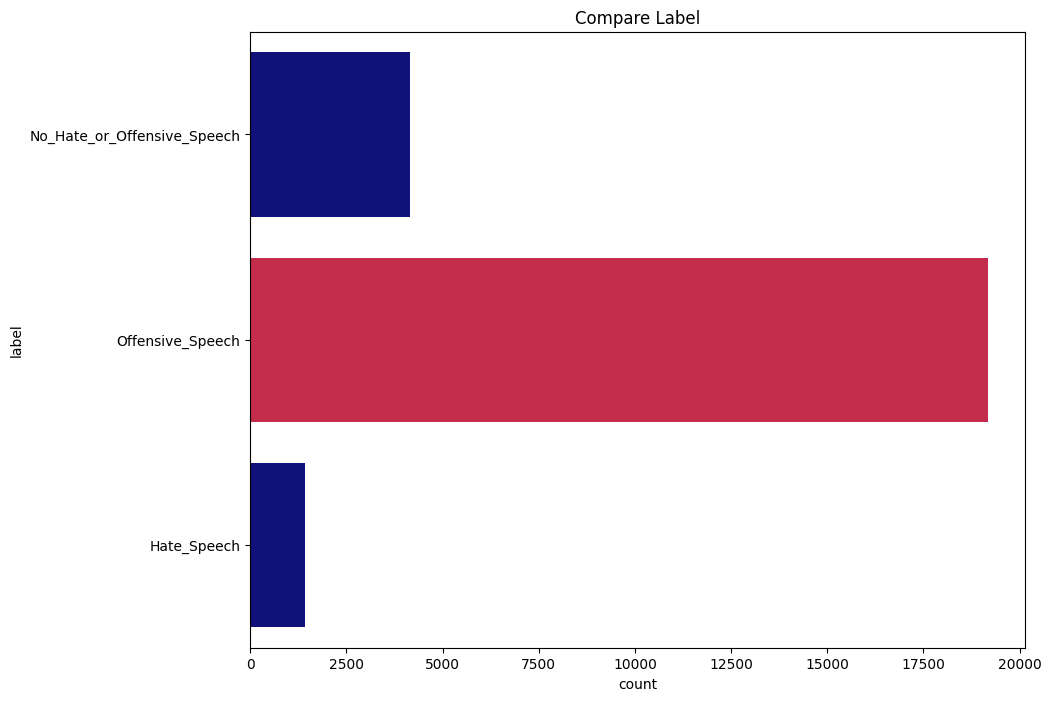

In [13]:
plt.figure(figsize=(10,8))
sns.countplot(data=df, y="label",palette=["darkblue","crimson"])
plt.title("Compare Label")
plt.show()

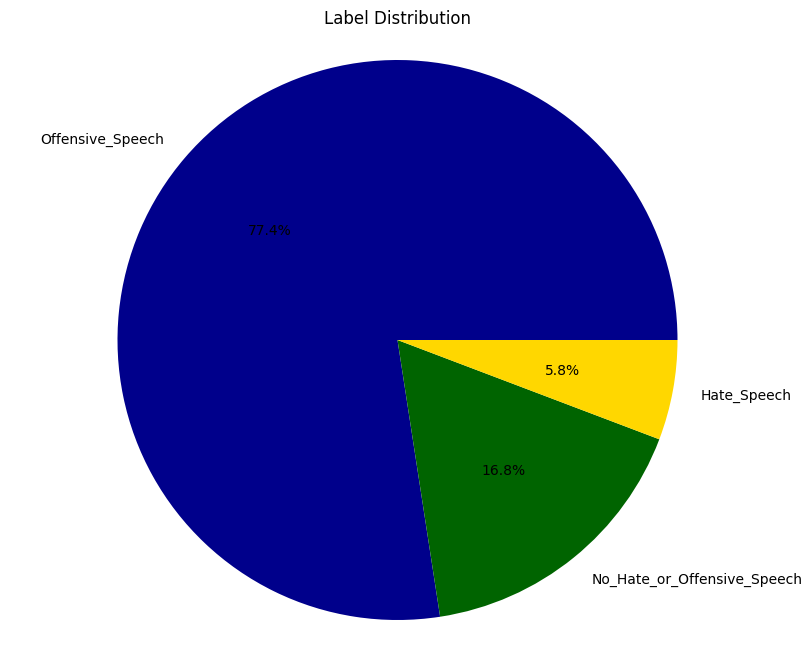

In [14]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(10,8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', colors=["darkblue", "darkgreen", "gold"])
plt.title("Label Distribution")
plt.axis("equal")
plt.show()

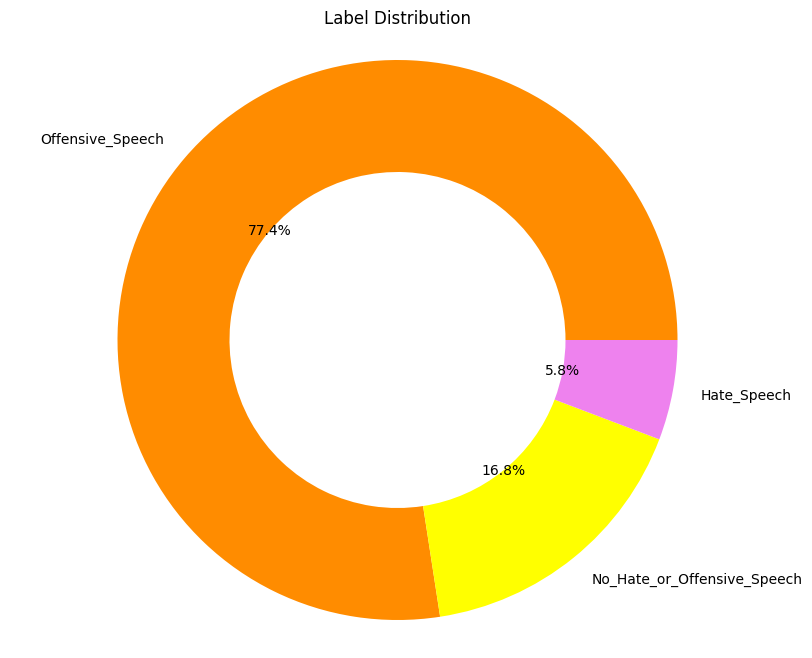

In [15]:
plt.figure(figsize=(10,8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', colors=["darkorange", "yellow", "violet"], wedgeprops=dict(width=0.4))
plt.title("Label Distribution")
plt.axis("equal")
plt.show()

In [16]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import string
from bs4 import BeautifulSoup

def clean_text(text):
    if isinstance(text, str):
        text = BeautifulSoup(text, 'html.parser').get_text()
        text = re.sub(r"[^a-zA-Z]", " ", text)
        text = text.translate(str.maketrans("", "", string.punctuation))

        emoji_pattern = re.compile("["
                                   u"\U0001F600-\U0001F64F"
                                   u"\U0001F300-\U0001F5FF"
                                   u"\U0001F680-\U0001F6FF"
                                   u"\U0001F1E0-\U0001F1FF"
                                   u"\U00002702-\U000027B0"
                                   u"\U000024C2-\U0001F251"
                                   "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)

        text = re.sub(r"#.*", "", text)
        text = re.sub(r"/\*.*?\*/", "", text, flags=re.DOTALL)
        text = text.lower()

       
        nltk_stop_words = set(stopwords.words('english'))
        tokens = word_tokenize(text)
        tokens = [word for word in tokens if word not in nltk_stop_words]

        text = ' '.join(tokens)

        return text
    else:
        return ""

In [17]:
df["tweet"]=df["tweet"].apply(clean_text)

<ipython-input-16-5a427ec412a1>:9: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, 'html.parser').get_text()


In [18]:
df.head()

,tweet,label
0,rt mayasolovely woman complain cleaning house ...,No_Hate_or_Offensive_Speech
1,rt mleew boy dats cold tyga dwn bad cuffin dat...,Offensive_Speech
2,rt urkindofbrand dawg rt sbaby life ever fuck ...,Offensive_Speech
3,rt c g anderson viva based look like tranny,Offensive_Speech
4,rt shenikaroberts shit hear might true might f...,Offensive_Speech


# Hate Speech Data Length

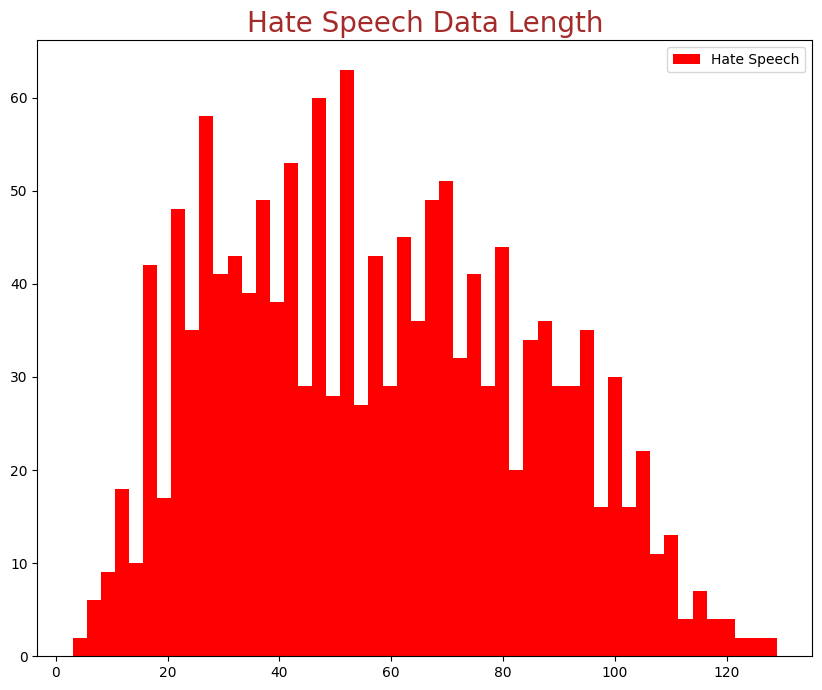

In [19]:
hatespeech_len=df[df["label"]=="Hate_Speech"]["tweet"].str.len()

plt.figure(figsize=(10,8))
plt.hist(hatespeech_len, bins=50,label='Hate Speech',color="red")
plt.title("Hate Speech Data Length",fontsize=20,color="brown")
plt.legend()
plt.show()

# Offensive Speech Data Length

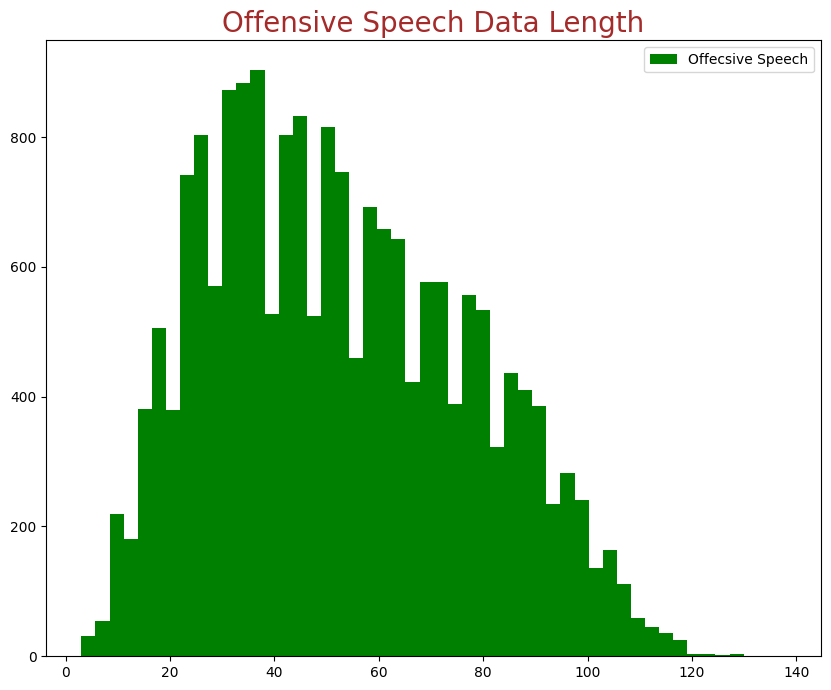

In [20]:
offensive_len=df[df["label"]=="Offensive_Speech"]["tweet"].str.len()

plt.figure(figsize=(10,8))
plt.hist(offensive_len, bins=50,label='Offecsive Speech',color="green")
plt.title("Offensive Speech Data Length",fontsize=20,color="brown")
plt.legend()
plt.show()

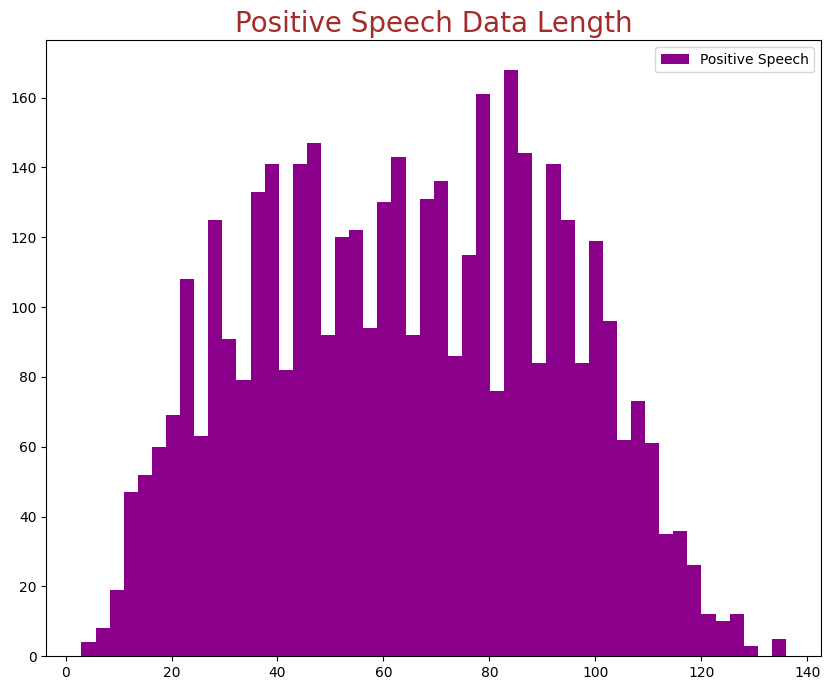

In [21]:

positive_len=df[df["label"]=="No_Hate_or_Offensive_Speech"]["tweet"].str.len()

plt.figure(figsize=(10,8))
plt.hist(positive_len, bins=50,label='Positive Speech',color="darkmagenta")
plt.title("Positive Speech Data Length",fontsize=20,color="brown")
plt.legend()
plt.show()

# Compare Data Length

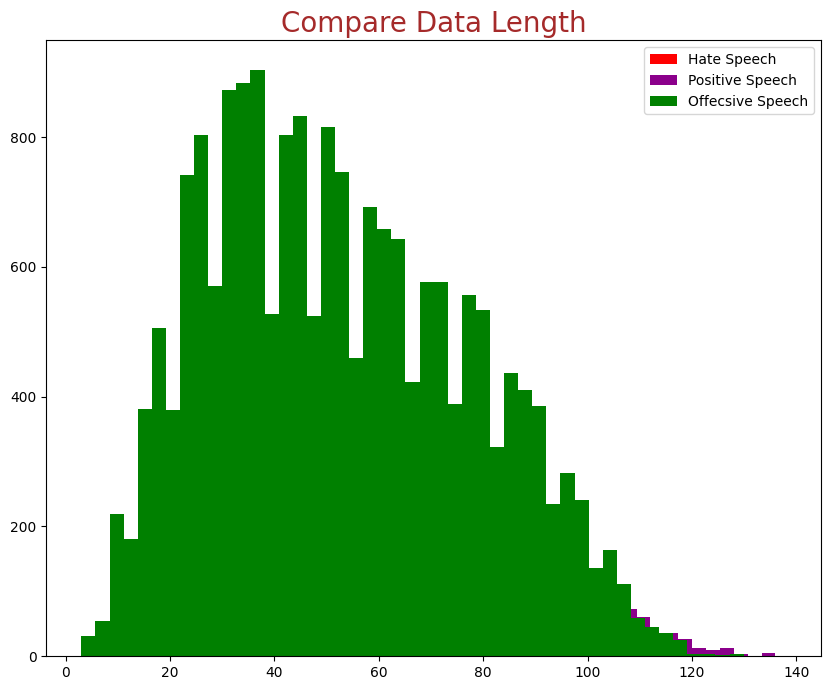

In [22]:
plt.figure(figsize=(10,8))
plt.hist(hatespeech_len, bins=50,label='Hate Speech',color="red")
plt.hist(positive_len, bins=50,label='Positive Speech',color="darkmagenta")
plt.hist(offensive_len, bins=50,label='Offecsive Speech',color="green")
plt.title("Compare Data Length",fontsize=20,color="brown")
plt.legend()
plt.show()

# Most Common Words From Positive Text

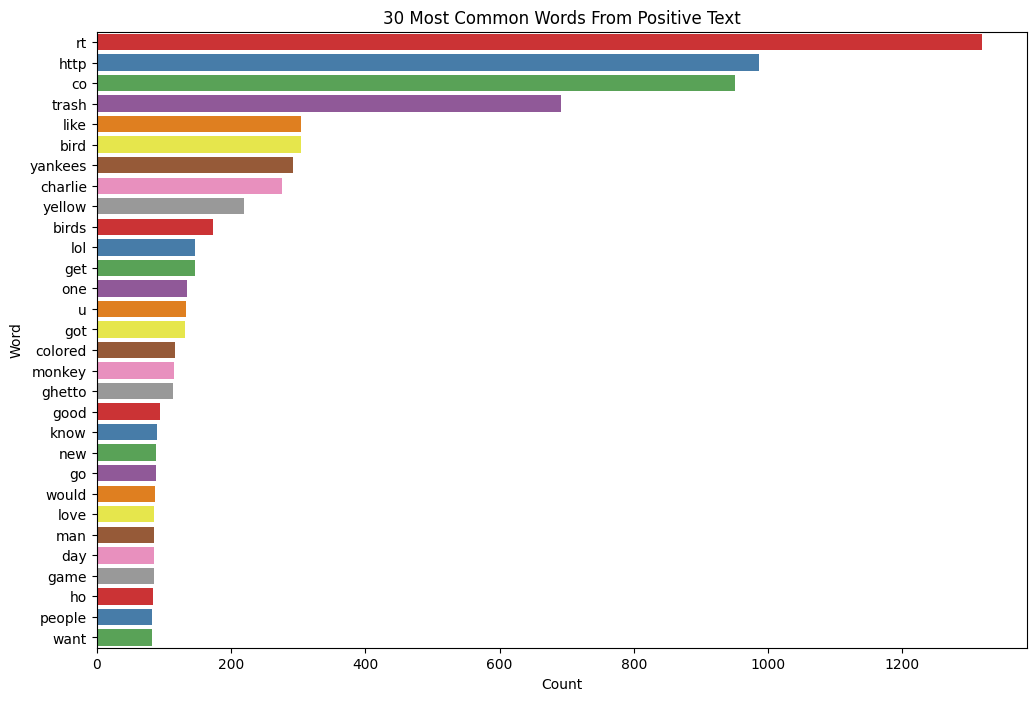

In [23]:
from collections import Counter
positive_text = df[df["label"] == "No_Hate_or_Offensive_Speech"]
data_set = positive_text["tweet"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_common_words,palette="Set1")
plt.title('30 Most Common Words From Positive Text')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# 30 Most Common Words From Offensive Text

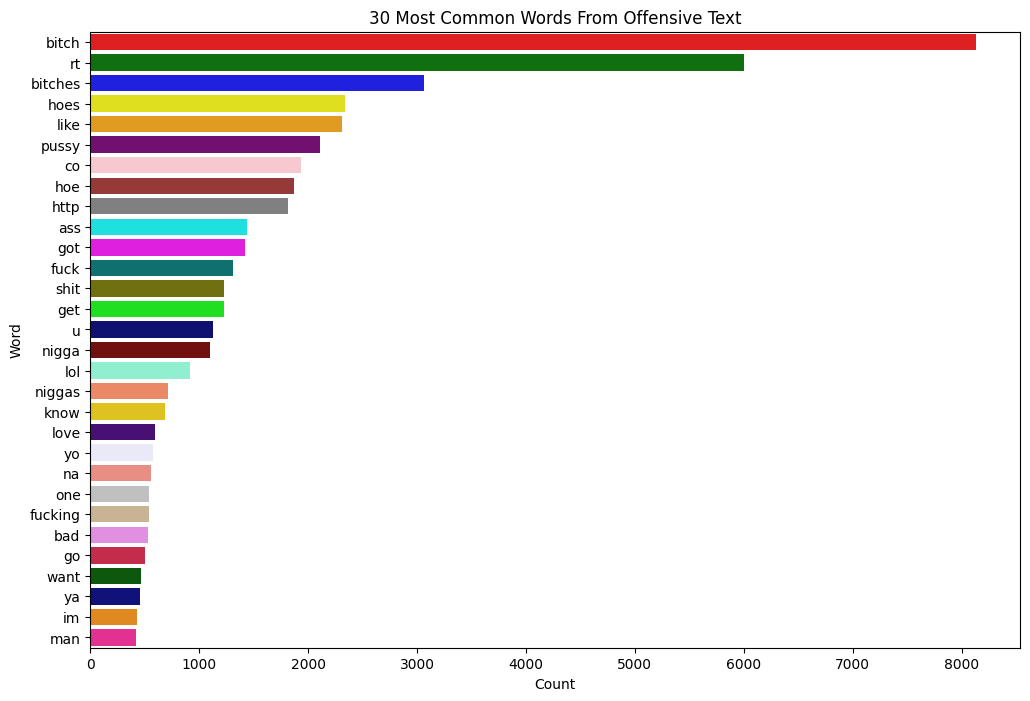

In [24]:
offensive_text = df[df["label"] == "Offensive_Speech"]
data_set = offensive_text["tweet"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
colors = ["red", "green", "blue", "yellow", "orange", "purple", "pink", "brown", "gray",
          "cyan", "magenta", "teal", "olive", "lime", "navy", "maroon", "aquamarine",
          "coral", "gold", "indigo", "lavender", "salmon", "silver", "tan", "violet",
          "crimson", "darkgreen", "darkblue", "darkorange", "deeppink"]
sns.barplot(x='Count', y='Word', data=df_common_words,palette=colors)
plt.title('30 Most Common Words From Offensive Text')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# 30 Most common Words From Hate Text

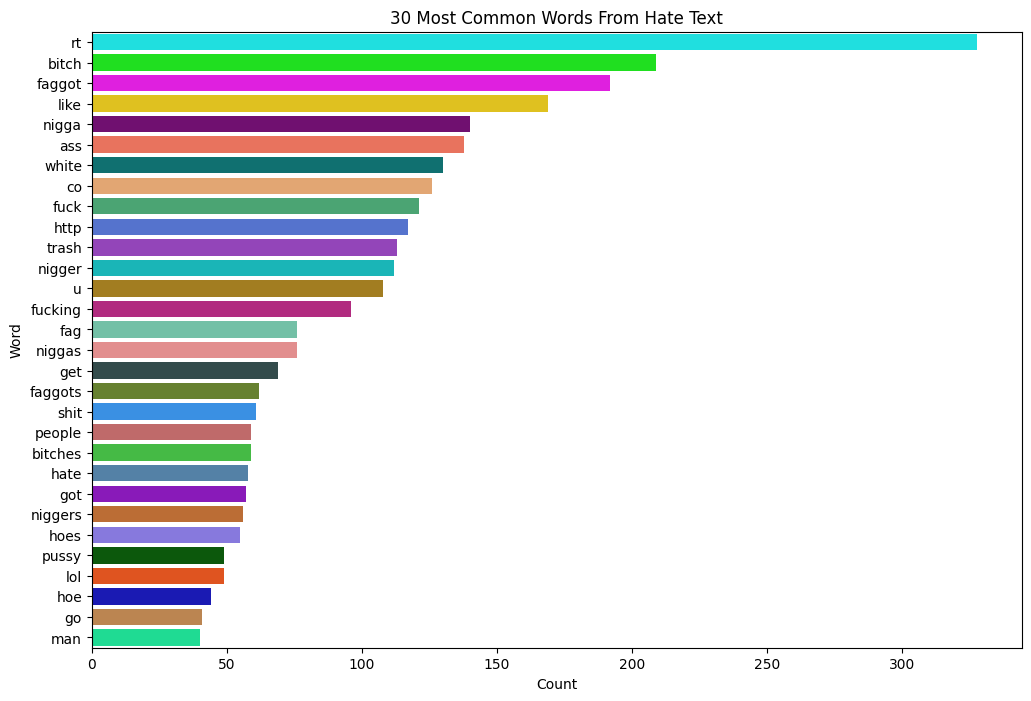

In [25]:
hate_text = df[df["label"] == "Hate_Speech"]
data_set = hate_text["tweet"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
colors = ["cyan", "lime", "magenta", "gold", "purple", "tomato", "teal", "sandybrown", "mediumseagreen",
          "royalblue", "darkorchid", "darkturquoise", "darkgoldenrod", "mediumvioletred", "mediumaquamarine",
          "lightcoral", "darkslategray", "olivedrab", "dodgerblue", "indianred", "limegreen", "steelblue",
          "darkviolet", "chocolate", "mediumslateblue", "darkgreen", "orangered", "mediumblue", "peru", "mediumspringgreen"]
sns.barplot(x='Count', y='Word', data=df_common_words,palette=colors)
plt.title('30 Most Common Words From Hate Text')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# Hate Data WordCloud

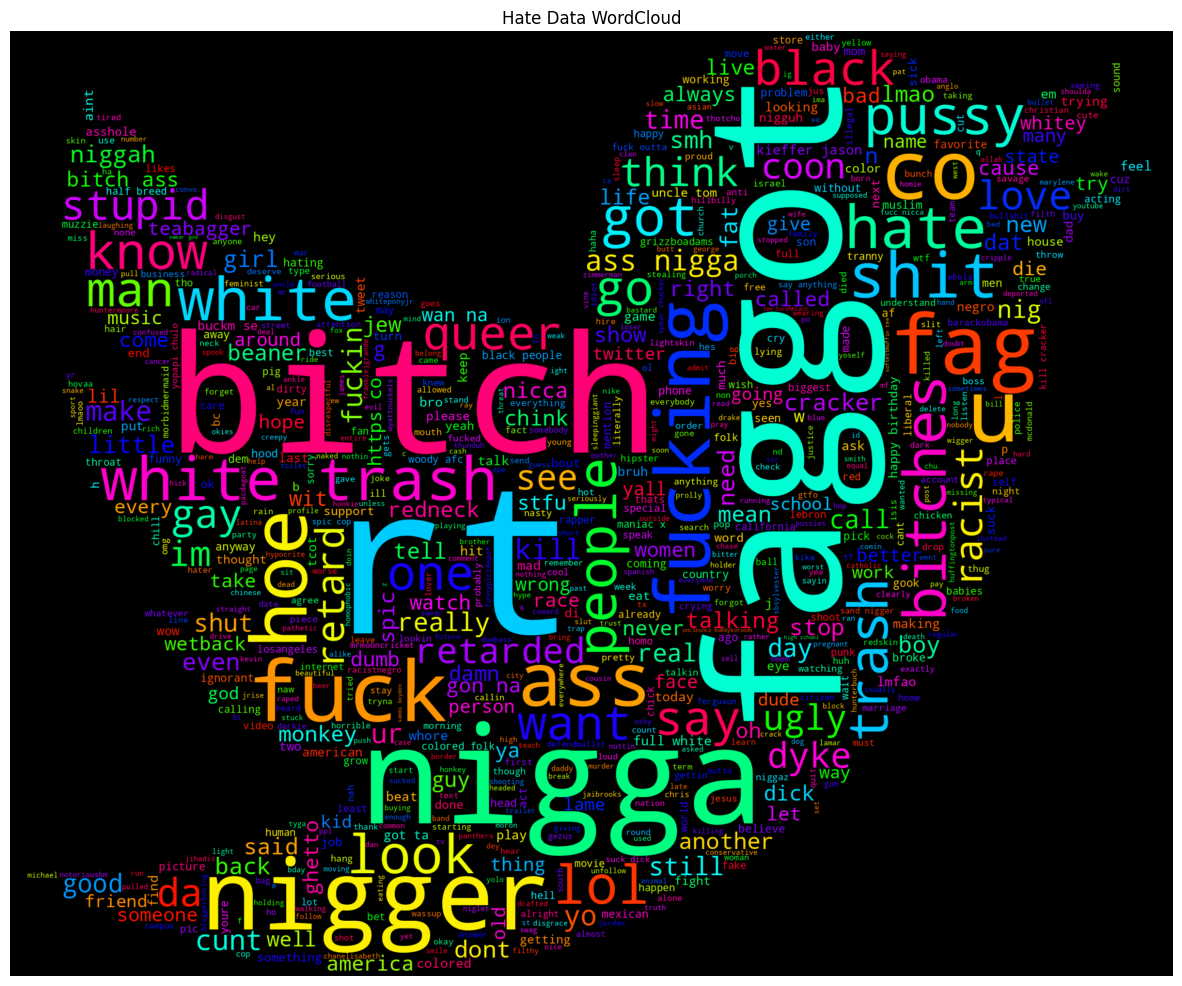

In [26]:
from wordcloud import WordCloud, STOPWORDS
plt.figure(figsize=(15,15))
hate_wordcloud=df[df["label"]=="Hate_Speech"]
hate_text=" ".join(hate_wordcloud['tweet'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="hsv",mask=mask).generate(hate_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Hate Data WordCloud")
plt.axis('off')
plt.show()

# Positive Data WordCloud

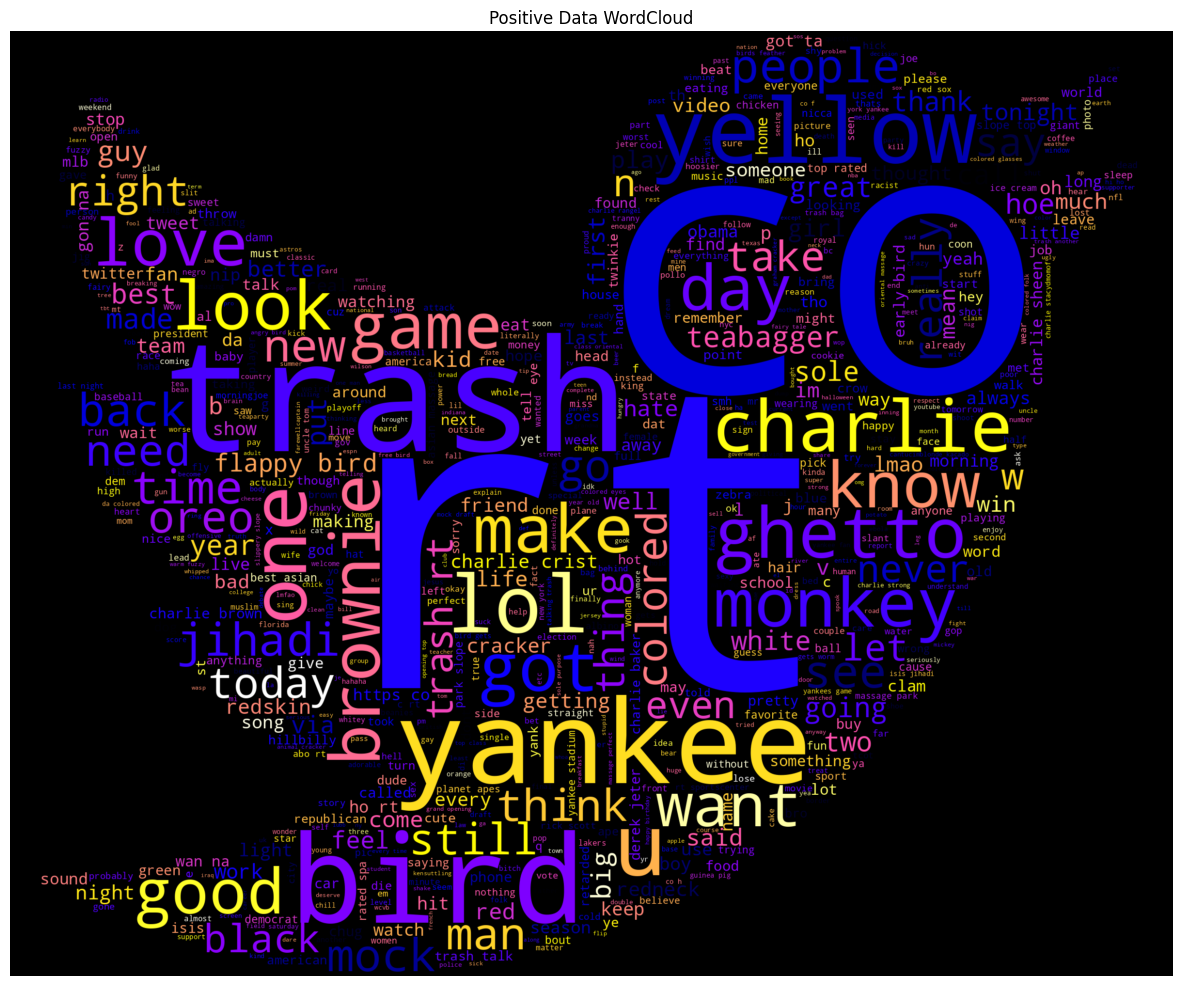

In [27]:
plt.figure(figsize=(15,15))
positive_wordcloud=df[df["label"]=="No_Hate_or_Offensive_Speech"]
positive_text=" ".join(positive_wordcloud['tweet'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="gnuplot2",mask=mask).generate(positive_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Positive Data WordCloud")
plt.axis('off')
plt.show()

# Offensive Data WordCloud

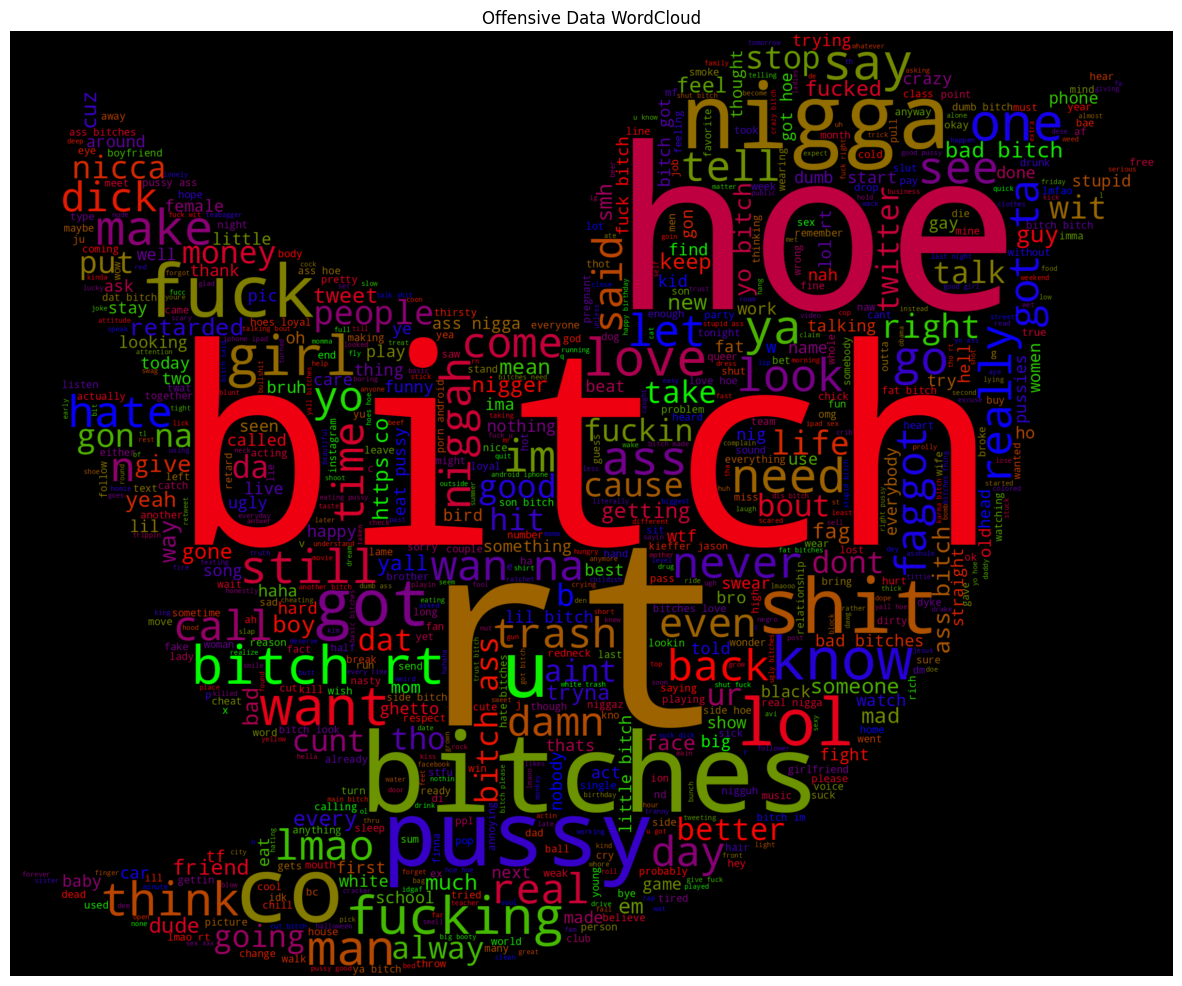

In [28]:
plt.figure(figsize=(15,15))
offensive_wordcloud=df[df["label"]=="Offensive_Speech"]
offensive_text=" ".join(offensive_wordcloud['tweet'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="brg",mask=mask).generate(offensive_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Offensive Data WordCloud")
plt.axis('off')
plt.show()

In [29]:
df.head()

,tweet,label
0,rt mayasolovely woman complain cleaning house ...,No_Hate_or_Offensive_Speech
1,rt mleew boy dats cold tyga dwn bad cuffin dat...,Offensive_Speech
2,rt urkindofbrand dawg rt sbaby life ever fuck ...,Offensive_Speech
3,rt c g anderson viva based look like tranny,Offensive_Speech
4,rt shenikaroberts shit hear might true might f...,Offensive_Speech


In [30]:
df["label"] = df["label"].map({"Hate_Speech":0,"Offensive_Speech":1,"No_Hate_or_Offensive_Speech":2})

In [31]:
label_name=["Hate Speech","Offensive Speech","No Hate & Offensive Speech"]

In [32]:
df.head()

,tweet,label
0,rt mayasolovely woman complain cleaning house ...,2
1,rt mleew boy dats cold tyga dwn bad cuffin dat...,1
2,rt urkindofbrand dawg rt sbaby life ever fuck ...,1
3,rt c g anderson viva based look like tranny,1
4,rt shenikaroberts shit hear might true might f...,1


# Calculate the length of each text in the dataset

In [33]:

text_lengths = df["tweet"].apply(len)

# Compute the average text length
average_text_length = np.mean(text_lengths)

print(f"Average text length: {average_text_length}")


Average text length: 55.00290521728604


In [34]:
text=df["tweet"].values
label=df["label"].values

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(text,label, test_size=0.2, random_state=42)


In [36]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
def tokenize(x_train, y_train, x_val, y_val, max_len=100):
    word_list = []

    for sent in x_train:
        for word in sent.lower().split():
            word_list.append(word)

    corpus = Counter(word_list)
    corpus_ = sorted(corpus, key=corpus.get, reverse=True)[:1000]
    onehot_dict = {w: i + 1 for i, w in enumerate(corpus_)}

    final_list_train, final_list_test = [], []
    for sent in x_train:
        final_list_train.append([onehot_dict[word] for word in sent.lower().split() if word in onehot_dict.keys()])
    for sent in x_val:
        final_list_test.append([onehot_dict[word] for word in sent.lower().split() if word in onehot_dict.keys()])

    final_list_train = pad_sequences(final_list_train, maxlen=max_len, padding='post', truncating='post')
    final_list_test = pad_sequences(final_list_test, maxlen=max_len, padding='post', truncating='post')

    encoded_train = [label for label in y_train]
    encoded_test = [label for label in y_val]

    return np.array(final_list_train), np.array(encoded_train), np.array(final_list_test), np.array(encoded_test), onehot_dict


In [37]:
X_train,y_train, X_test, y_test, vocab = tokenize(X_train, y_train, X_test, y_test)

# Padding

In [38]:
def padding_data(sentences, seq_len):
    features = np.zeros((len(sentences), seq_len),dtype=int)
    for ii, review in enumerate(sentences):
        if len(review) != 0:
            features[ii, -len(review):] = np.array(review)[:seq_len]
    return features

In [39]:
X_train_pad = padding_data(X_train,100)
X_test_pad = padding_data(X_test,100)

# Patching and Loading as Tensor

In [40]:

from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from tqdm import tqdm

train_data = TensorDataset(torch.from_numpy(X_train_pad), torch.from_numpy(y_train))
valid_data = TensorDataset(torch.from_numpy(X_test_pad), torch.from_numpy(y_test))
batch_size = 16
train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=batch_size)

In [41]:
dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)

In [42]:
sample_x

tensor([[  2,   9, 924,  ...,   0,   0,   0],
        [  2, 536,   3,  ...,   0,   0,   0],
        [  2,  13,   7,  ...,   0,   0,   0],
        ...,
        [  2,   7, 659,  ...,   0,   0,   0],
        [  2, 102,   5,  ...,   0,   0,   0],
        [707, 244,  29,  ...,   0,   0,   0]])

In [43]:
sample_y

tensor([1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 0, 1])

# Create GRU Model

In [44]:
import torch
import torch.nn as nn

class SentimentGRU(nn.Module):
    def __init__(self, no_layers, vocab_size, hidden_dim, embedding_dim, output_dim=3, drop_prob=0.5):
        super(SentimentGRU, self).__init__()
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.no_layers = no_layers
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(input_size=embedding_dim, hidden_size=hidden_dim, num_layers=no_layers, batch_first=True)
        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden):
        embeds = self.embedding(x)
        gru_out, hidden = self.gru(embeds, hidden)
        gru_out = gru_out.contiguous().view(-1, self.hidden_dim)
        out = self.dropout(gru_out)
        out = self.fc(out)
        batch_size = x.size(0)
        out = out.view(batch_size, -1, self.output_dim)
        out = out[:, -1, :]
        return out, hidden

    def init_hidden(self, batch_size):
        h0= torch.zeros((self.no_layers, batch_size, self.hidden_dim)).to(device)
        return h0
       
       


In [45]:
no_layers = 2
vocab_size = len(vocab) + 1
embedding_dim = 64
output_dim = 3
hidden_dim = 256
model = SentimentGRU(no_layers,vocab_size,hidden_dim,embedding_dim,output_dim,drop_prob=0.5).to(device)
model

SentimentGRU(
  (embedding): Embedding(1001, 64)
  (gru): GRU(64, 256, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

In [46]:
criterion=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def acc(pred, label):
    _, pred_labels = torch.max(pred, 1)
    correct = torch.sum(pred_labels == label).item()
    return correct


In [47]:
from tabulate import tabulate

clip = 5
epochs = 20
valid_loss_min = np.Inf
epoch_tr_loss, epoch_vl_loss = [], []
epoch_tr_acc, epoch_vl_acc = [], []

headers = ["Epoch", "Train Loss", "Train Accuracy", "Validation Loss", "Validation Accuracy"]

for epoch in range(epochs):
    train_losses = []
    train_acc = 0.0
    model.train()

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch"):
        inputs, labels = inputs.to(device), labels.to(device)
        batch_size = inputs.size(0)
        h = model.init_hidden(batch_size)

        h = h.detach()

        model.zero_grad()
        output, h = model(inputs, h)

        loss = criterion(output, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        train_losses.append(loss.item())
        train_acc += acc(output, labels)

    val_losses = []
    val_acc = 0.0
    model.eval()

    for inputs, labels in tqdm(valid_loader, desc="Validation", unit="batch"):
        inputs, labels = inputs.to(device), labels.to(device)
        batch_size = inputs.size(0)
        val_h = model.init_hidden(batch_size)

        val_h = val_h.detach()

        with torch.no_grad():
            output, val_h = model(inputs, val_h)
            val_losses.append(criterion(output, labels).item())
            val_acc += acc(output, labels)

    epoch_train_loss = np.mean(train_losses)
    epoch_val_loss = np.mean(val_losses)
    epoch_train_acc = train_acc / len(train_loader.dataset)
    epoch_val_acc = val_acc / len(valid_loader.dataset)

    epoch_tr_loss.append(epoch_train_loss)
    epoch_vl_loss.append(epoch_val_loss)
    epoch_tr_acc.append(epoch_train_acc)
    epoch_vl_acc.append(epoch_val_acc)

    epoch_data = [
        [epoch + 1, 
         f"{epoch_train_loss:.3f}", 
         f"{epoch_train_acc*100:.2f}%", 
         f"{epoch_val_loss:.3f}", 
         f"{epoch_val_acc*100:.2f}%"]
    ]
    
    print(tabulate(epoch_data, headers, tablefmt="fancy_grid"))

    if epoch_val_loss < valid_loss_min:
        valid_loss_min = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pkl")
        print("Validation loss improved, saving model to best_model.pkl")


Validation: 100%|██████████| 310/310 [00:01<00:00, 307.52batch/s]


╒═════════╤══════════════╤══════════════════╤═══════════════════╤═══════════════════════╕
│   Epoch │   Train Loss │ Train Accuracy   │   Validation Loss │ Validation Accuracy   │
╞═════════╪══════════════╪══════════════════╪═══════════════════╪═══════════════════════╡
│       1 │        0.679 │ 77.44%           │             0.666 │ 77.30%                │
╘═════════╧══════════════╧══════════════════╧═══════════════════╧═══════════════════════╛
Validation loss improved, saving model to best_model.pkl


Validation: 100%|██████████| 310/310 [00:01<00:00, 306.01batch/s]


╒═════════╤══════════════╤══════════════════╤═══════════════════╤═══════════════════════╕
│   Epoch │   Train Loss │ Train Accuracy   │   Validation Loss │ Validation Accuracy   │
╞═════════╪══════════════╪══════════════════╪═══════════════════╪═══════════════════════╡
│       2 │        0.673 │ 77.46%           │             0.671 │ 77.30%                │
╘═════════╧══════════════╧══════════════════╧═══════════════════╧═══════════════════════╛


Validation: 100%|██████████| 310/310 [00:01<00:00, 306.56batch/s]


...

╒═════════╤══════════════╤══════════════════╤═══════════════════╤═══════════════════════╕
│   Epoch │   Train Loss │ Train Accuracy   │   Validation Loss │ Validation Accuracy   │
╞═════════╪══════════════╪══════════════════╪═══════════════════╪═══════════════════════╡
│      18 │        0.057 │ 98.17%           │             0.595 │ 86.46%                │
╘═════════╧══════════════╧══════════════════╧═══════════════════╧═══════════════════════╛


Validation: 100%|██████████| 310/310 [00:01<00:00, 307.85batch/s]


╒═════════╤══════════════╤══════════════════╤═══════════════════╤═══════════════════════╕
│   Epoch │   Train Loss │ Train Accuracy   │   Validation Loss │ Validation Accuracy   │
╞═════════╪══════════════╪══════════════════╪═══════════════════╪═══════════════════════╡
│      19 │        0.049 │ 98.38%           │             0.587 │ 88.48%                │
╘═════════╧══════════════╧══════════════════╧═══════════════════╧═══════════════════════╛


Validation: 100%|██████████| 310/310 [00:01<00:00, 305.86batch/s]

╒═════════╤══════════════╤══════════════════╤═══════════════════╤═══════════════════════╕
│   Epoch │   Train Loss │ Train Accuracy   │   Validation Loss │ Validation Accuracy   │
╞═════════╪══════════════╪══════════════════╪═══════════════════╪═══════════════════════╡
│      20 │        0.052 │ 98.25%           │             0.577 │ 87.49%                │
╘═════════╧══════════════╧══════════════════╧═══════════════════╧═══════════════════════╛


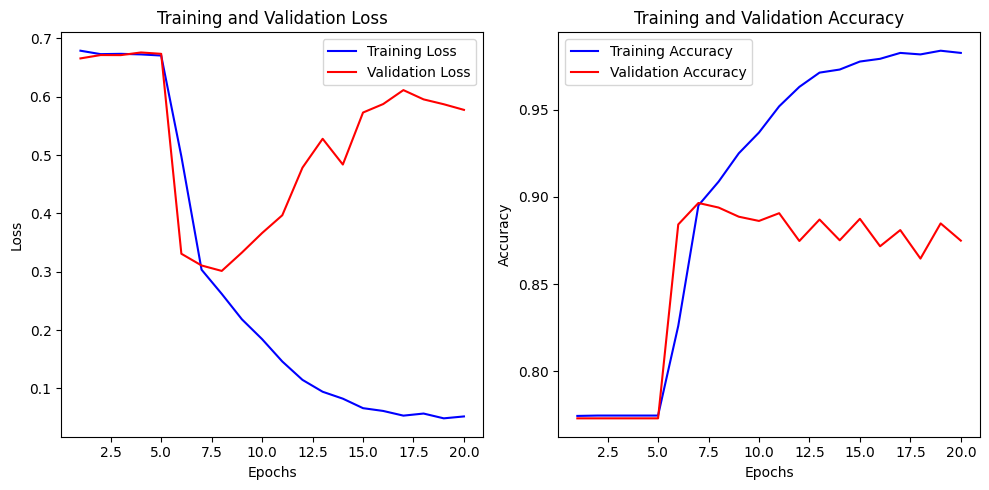

In [48]:

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), epoch_tr_loss, label='Training Loss', color='blue')
plt.plot(range(1, epochs + 1), epoch_vl_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), epoch_tr_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, epochs + 1), epoch_vl_acc, label='Validation Accuracy', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


In [49]:

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(valid_loader, desc="Validation", unit="batch"):
        inputs, labels = inputs.to(device), labels.to(device)
        batch_size = inputs.size(0)
        hidden = model.init_hidden(batch_size)  
        output, hidden = model(inputs, hidden)  
        _, preds = torch.max(output, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)



Validation: 100%|██████████| 310/310 [00:00<00:00, 311.64batch/s]


# confusion_matrix

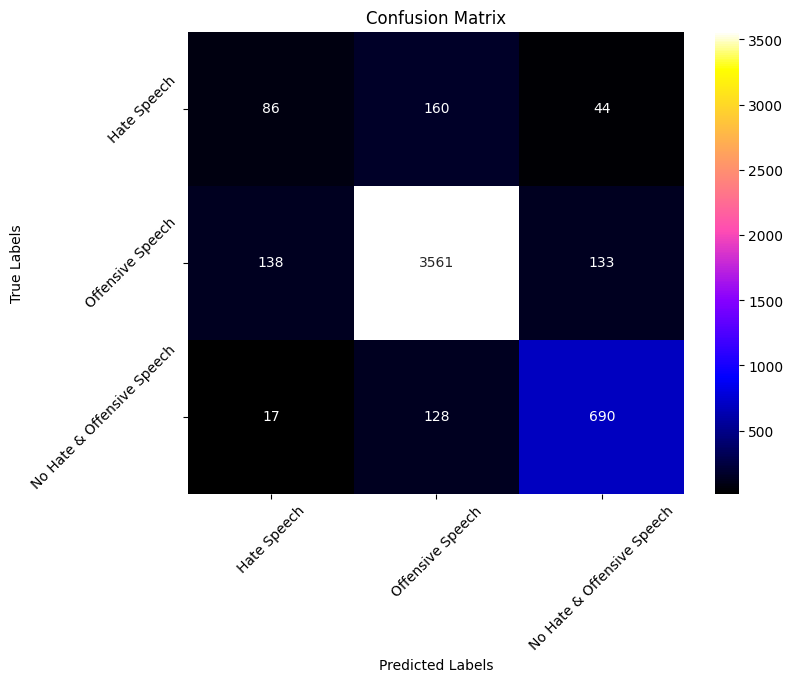

In [50]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='gnuplot2', xticklabels=label_name, yticklabels=label_name)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()


In [51]:
print(classification_report(all_labels,all_preds,target_names=label_name))

                            precision    recall  f1-score   support

               Hate Speech       0.36      0.30      0.32       290
          Offensive Speech       0.93      0.93      0.93      3832
No Hate & Offensive Speech       0.80      0.83      0.81       835

                  accuracy                           0.87      4957
                 macro avg       0.69      0.68      0.69      4957
              weighted avg       0.87      0.87      0.87      4957



In [52]:
print(label_name)

['Hate Speech', 'Offensive Speech', 'No Hate & Offensive Speech']


In [53]:
y_true=all_labels
y_pred=all_preds

# Roc Curve

Validation: 100%|██████████| 310/310 [00:00<00:00, 312.89batch/s]


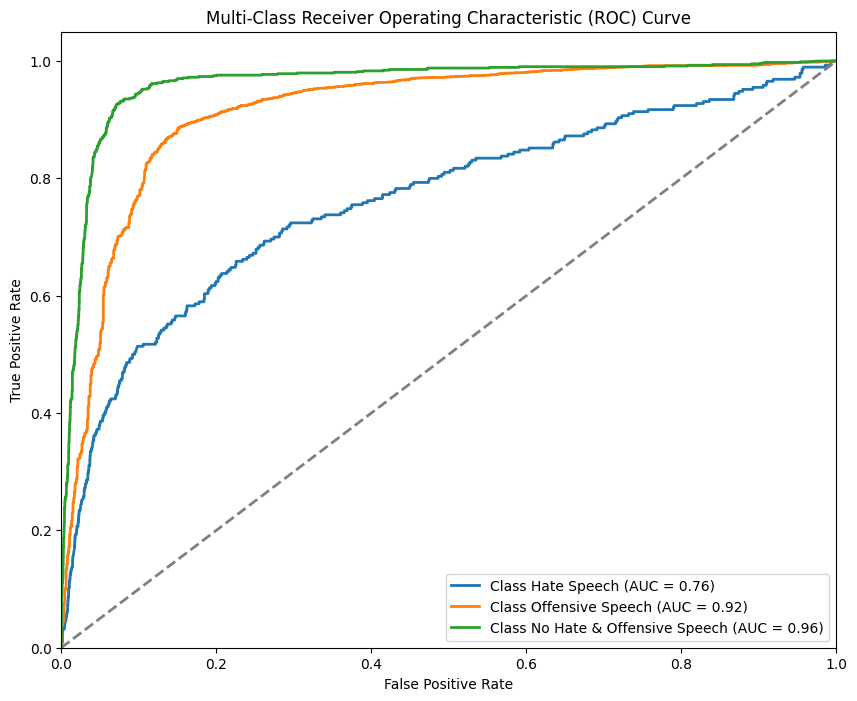

In [54]:


label_names = ['Hate Speech', 'Offensive Speech', 'No Hate & Offensive Speech']
num_classes = len(label_names)

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(valid_loader, desc="Validation", unit="batch"):
        inputs, labels = inputs.to(device), labels.to(device)
        batch_size = inputs.size(0)
        hidden = model.init_hidden(batch_size)
        output, hidden = model(inputs, hidden)
        all_preds.extend(output.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_labels = label_binarize(all_labels, classes=[i for i in range(num_classes)])

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {label_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


# precision Recall Curve

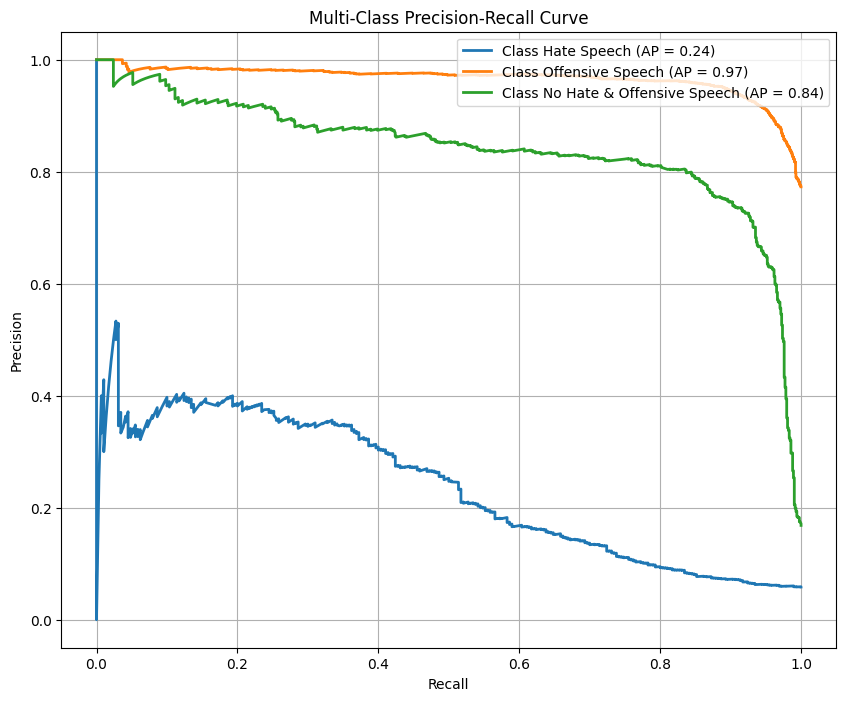

In [55]:
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
    avg_precision = average_precision_score(all_labels[:, i], all_preds[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {label_names[i]} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-Class Precision-Recall Curve')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Accuracy Score

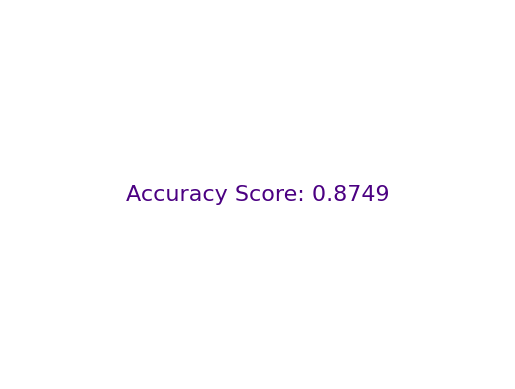

In [56]:
accuracy = accuracy_score(y_true, y_pred)
plt.plot([])
plt.text(0, 0, f'Accuracy Score: {accuracy:.4f}', fontsize=16, ha='center', va='center', color="indigo")
plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.show()

# Roc Auc Score

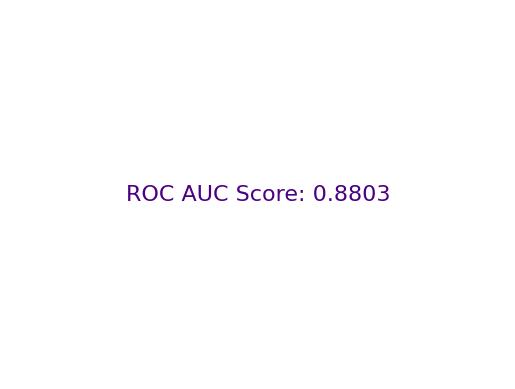

In [57]:
y_pred = np.array(all_preds)
y_true = np.array(all_labels)

if y_pred.ndim == 1 or y_pred.shape[1] != len(label_names):
    raise ValueError("y_pred must be a 2D array with probabilities for each class.")

roc_auc = roc_auc_score(y_true, y_pred, multi_class="ovr")

plt.plot([])
plt.text(0, 0, f'ROC AUC Score: {roc_auc:.4f}', fontsize=16, ha='center', va='center', color="indigo")
plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.show()

# Log Loss

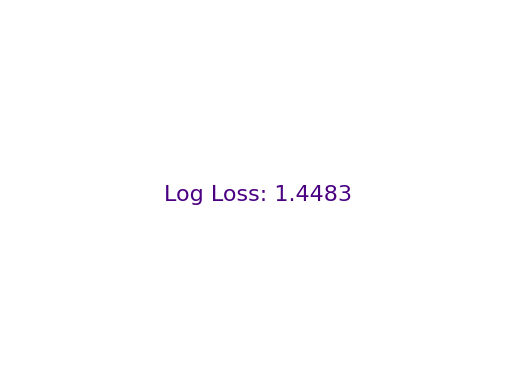

In [58]:


log_loss_value = log_loss(y_true, y_pred)

plt.plot([])
plt.text(0, 0, f'Log Loss: {log_loss_value:.4f}', fontsize=16, ha='center', va='center', color="indigo")
plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.show()


# Kappa Score

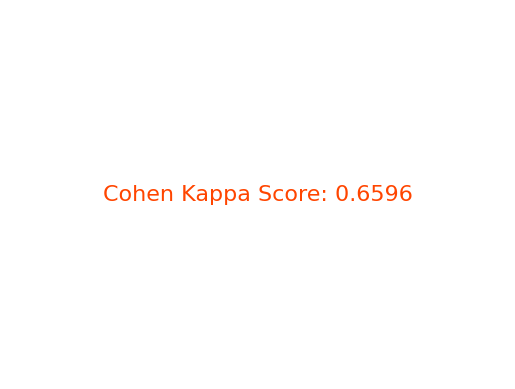

In [59]:
from sklearn.metrics import cohen_kappa_score
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_true, axis=1)  
kappa = cohen_kappa_score(y_true_labels, y_pred_labels)

plt.plot([])
plt.text(0, 0, f'Cohen Kappa Score: {kappa:.4f}', fontsize=16, ha='center', va='center', color="orangered")
plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.show()

# matthews_corrcoef

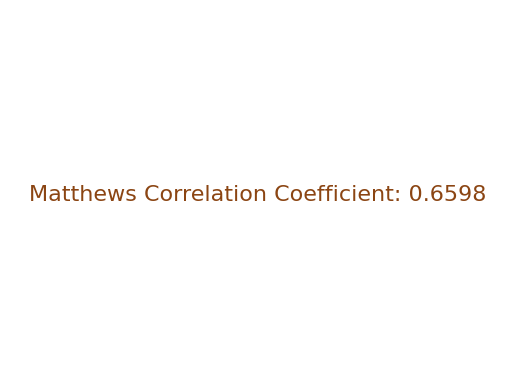

In [60]:
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_true_labels,y_pred_labels)

# Create a plot and display the MCC value as text
plt.plot([])
plt.text(0,0, f'Matthews Correlation Coefficient: {mcc:.4f}', fontsize=16, ha='center', va='center',color="saddlebrown")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

# Custom Data Prediction

In [61]:
import numpy as np
import torch
from tensorflow.keras.preprocessing.sequence import pad_sequences

custom_texts = [
    "I absolutely hate how people always get away with being rude on the internet. It's frustrating to see others spreading negativity without any consequences.",
    "The weather today is nice and sunny, making it perfect for a walk in the park. I’m planning to go out for a while and enjoy the fresh air.",
    "You are so stupid, I can't stand people like you. Just go away, nobody cares about your opinion!"
]

def tokenize_custom_data(texts, max_len=100):
    word_list = []
    for sent in texts:
        for word in sent.lower().split():
            word_list.append(word)
    corpus = Counter(word_list)
    corpus_ = sorted(corpus, key=corpus.get, reverse=True)[:1000]
    onehot_dict = {w: i + 1 for i, w in enumerate(corpus_)}
    tokenized_data = []
    for sent in texts:
        tokenized_data.append([onehot_dict[word] for word in sent.lower().split() if word in onehot_dict.keys()])
    padded_data = pad_sequences(tokenized_data, maxlen=max_len, padding='post', truncating='post')
    return padded_data

X_custom = tokenize_custom_data(custom_texts)
X_custom_tensor = torch.from_numpy(X_custom).to(device)


h0 = torch.zeros(no_layers, X_custom_tensor.size(0), hidden_dim).to(device)

model.eval()
with torch.no_grad():
    outputs, _ = model(X_custom_tensor, h0)
    predictions = torch.argmax(outputs, dim=1).cpu().numpy()

label_map = {0: "Hate_Speech", 1: "Offensive_Speech", 2: "No_Hate_or_Offensive_Speech"}

for text, pred in zip(custom_texts, predictions):
    print(f"Text: {text}\nPredicted Label: {label_map[pred]}\n")
    print("####################################################################################################")


Text: I absolutely hate how people always get away with being rude on the internet. It's frustrating to see others spreading negativity without any consequences.
Predicted Label: Offensive_Speech

####################################################################################################
Text: The weather today is nice and sunny, making it perfect for a walk in the park. I’m planning to go out for a while and enjoy the fresh air.
Predicted Label: Offensive_Speech

####################################################################################################
Text: You are so stupid, I can't stand people like you. Just go away, nobody cares about your opinion!
Predicted Label: Offensive_Speech

####################################################################################################
